In [5]:
import random
import matplotlib.pyplot as plt

# Data Mata Kuliah
courses = [
    ("AI", "DosenA"),
    ("ML", "DosenB"),
    ("DB", "DosenC"),
    ("CN", "DosenD"),
    ("SE", "DosenE"),
    ("OS", "DosenF"),
    ("IR", "DosenA"),
    ("NLP", "DosenB"),
    ("CV", "DosenC"),
    ("IOT", "DosenD"),
    ("HCI", "DosenE"),
    ("CyberSec", "DosenF"),
    ("BigData", "DosenA"),
    ("DL", "DosenB"),
    ("NoSQL", "DosenC"),
    ("Cloud", "DosenD"),
    ("UX", "DosenE"),
    ("SecEng", "DosenF"),
    ("Agile", "DosenA"),
    ("RL", "DosenB"),
    ("ETL", "DosenC"),
    ("DevOps", "DosenD"),
    ("GameDev", "DosenE"),
    ("Blockchain", "DosenF")
]

# Data Ruang
rooms = ["R1", "R2", "R3", "R4"]

# Data Slot Waktu
timeslots = [
    "Senin-08",
    "Senin-10",
    "Senin-13",
    "Selasa-08",
    "Selasa-10",
    "Selasa-13",
    "Rabu-08",
    "Rabu-10",
    "Rabu-13",
    "Kamis-08",
    "Kamis-10",
    "Kamis-13"
]

# Parameter Genetic Algorithm
POPULATION_SIZE = 60
GENERATIONS = 100
CROSSOVER_RATE = 0.85
MUTATION_RATE = 0.20

In [6]:
def create_individual():
    individual = []

    for course in courses:
        room = random.choice(rooms)
        slot = random.choice(timeslots)

        individual.append((course[0], course[1], room, slot))

    return individual


def create_population():
    return [create_individual() for _ in range(POPULATION_SIZE)]

In [7]:
def fitness(individual):

    konflik = 0

    room_time = {}
    lecturer_time = {}
    lecturer_day = {}

    for course, lecturer, room, slot in individual:

        # Konflik Ruang
        key = (room, slot)
        if key in room_time:
            konflik += 1
        else:
            room_time[key] = course

        # Konflik Dosen-Waktu
        key = (lecturer, slot)
        if key in lecturer_time:
            konflik += 1
        else:
            lecturer_time[key] = course

        # Konflik Dosen-Hari
        day = slot.split("-")[0]

        key = (lecturer, day)

        if key in lecturer_day:
            konflik += 1
        else:
            lecturer_day[key] = course

    nilai_fitness = max(0, 100 - konflik)

    return nilai_fitness, konflik

In [8]:
def selection(population):

    kandidat = random.sample(population, 3)

    kandidat.sort(key=lambda x: fitness(x)[0], reverse=True)

    return kandidat[0]

In [9]:
def crossover(parent1, parent2):

    if random.random() > CROSSOVER_RATE:
        return parent1.copy(), parent2.copy()

    point = random.randint(1, len(parent1)-2)

    child1 = parent1[:point] + parent2[point:]

    child2 = parent2[:point] + parent1[point:]

    return child1, child2

In [10]:
def mutation(individual):

    for i in range(len(individual)):

        if random.random() < MUTATION_RATE:

            course, lecturer, room, slot = individual[i]

            room = random.choice(rooms)
            slot = random.choice(timeslots)

            individual[i] = (course, lecturer, room, slot)

    return individual

In [11]:
# ==========================================
# PROGRAM UTAMA GENETIC ALGORITHM
# ==========================================

population = create_population()

best_history = []
avg_history = []

for generation in range(GENERATIONS):

    new_population = []

    while len(new_population) < POPULATION_SIZE:

        parent1 = selection(population)
        parent2 = selection(population)

        child1, child2 = crossover(parent1, parent2)

        child1 = mutation(child1)
        child2 = mutation(child2)

        new_population.append(child1)

        if len(new_population) < POPULATION_SIZE:
            new_population.append(child2)

    population = new_population

    fitness_values = [fitness(ind)[0] for ind in population]

    best = max(fitness_values)
    avg = sum(fitness_values) / len(fitness_values)

    best_history.append(best)
    avg_history.append(avg)

    print(f"Generasi {generation+1}")
    print(f"Fitness Maksimum : {best}")
    print(f"Fitness Rata-rata : {avg:.2f}")
    print("-" * 40)

Generasi 1
Fitness Maksimum : 92
Fitness Rata-rata : 85.67
----------------------------------------
Generasi 2
Fitness Maksimum : 91
Fitness Rata-rata : 86.03
----------------------------------------
Generasi 3
Fitness Maksimum : 92
Fitness Rata-rata : 86.60
----------------------------------------
Generasi 4
Fitness Maksimum : 93
Fitness Rata-rata : 86.07
----------------------------------------
Generasi 5
Fitness Maksimum : 93
Fitness Rata-rata : 86.77
----------------------------------------
Generasi 6
Fitness Maksimum : 93
Fitness Rata-rata : 85.98
----------------------------------------
Generasi 7
Fitness Maksimum : 92
Fitness Rata-rata : 86.77
----------------------------------------
Generasi 8
Fitness Maksimum : 93
Fitness Rata-rata : 86.43
----------------------------------------
Generasi 9
Fitness Maksimum : 92
Fitness Rata-rata : 85.93
----------------------------------------
Generasi 10
Fitness Maksimum : 93
Fitness Rata-rata : 86.85
----------------------------------------

In [12]:
# ==========================================
# MENAMPILKAN JADWAL TERBAIK
# ==========================================

best_individual = max(population, key=lambda x: fitness(x)[0])

nilai_fitness, konflik = fitness(best_individual)

print("\n===== JADWAL TERBAIK =====\n")

for course, lecturer, room, slot in best_individual:
    print(f"{course:12} | {lecturer:8} | {room} | {slot}")

print("\nFitness Terbaik :", nilai_fitness)
print("Jumlah Konflik :", konflik)


===== JADWAL TERBAIK =====

AI           | DosenA   | R3 | Selasa-13
ML           | DosenB   | R4 | Rabu-08
DB           | DosenC   | R4 | Selasa-13
CN           | DosenD   | R2 | Rabu-13
SE           | DosenE   | R4 | Rabu-13
OS           | DosenF   | R1 | Senin-13
IR           | DosenA   | R1 | Rabu-10
NLP          | DosenB   | R3 | Kamis-13
CV           | DosenC   | R3 | Rabu-08
IOT          | DosenD   | R1 | Kamis-10
HCI          | DosenE   | R2 | Selasa-10
CyberSec     | DosenF   | R4 | Kamis-10
BigData      | DosenA   | R1 | Senin-13
DL           | DosenB   | R1 | Rabu-13
NoSQL        | DosenC   | R3 | Selasa-10
Cloud        | DosenD   | R2 | Kamis-13
UX           | DosenE   | R4 | Selasa-08
SecEng       | DosenF   | R3 | Selasa-08
Agile        | DosenA   | R4 | Selasa-08
RL           | DosenB   | R3 | Senin-13
ETL          | DosenC   | R1 | Senin-10
DevOps       | DosenD   | R3 | Senin-08
GameDev      | DosenE   | R1 | Kamis-08
Blockchain   | DosenF   | R1 | Senin-10

Fitness T

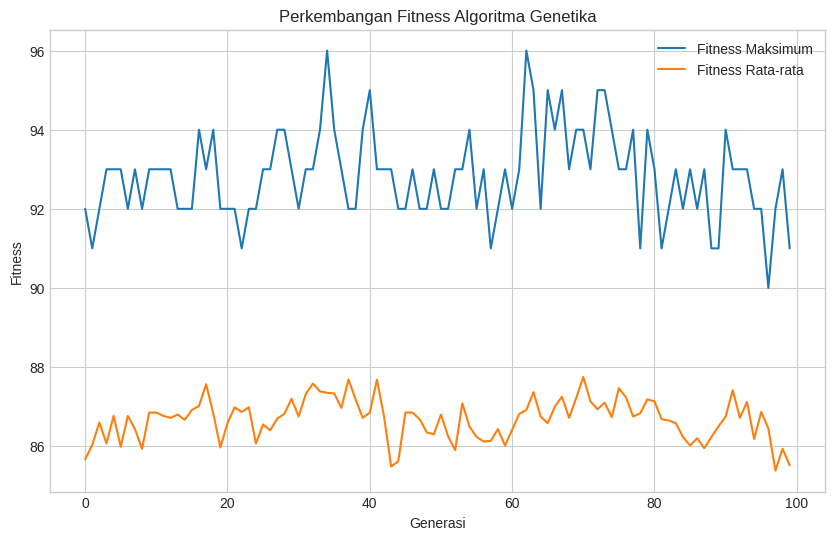

In [13]:
# ==========================================
# GRAFIK FITNESS
# ==========================================

plt.figure(figsize=(10,6))

plt.plot(best_history, label="Fitness Maksimum")
plt.plot(avg_history, label="Fitness Rata-rata")

plt.title("Perkembangan Fitness Algoritma Genetika")
plt.xlabel("Generasi")
plt.ylabel("Fitness")

plt.grid(True)
plt.legend()

plt.show()